In [1]:
# 📦 Schritt 1: Bibliotheken importieren
import pandas as pd
import glob
import os

# 📁 Schritt 2: Pfad zu den Metrics-Dateien definieren
folder_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_multiple_seeds/"
file_pattern = os.path.join(folder_path, "Metrics_*.csv")

# 📂 Schritt 3: Alle passenden CSV-Dateien finden
file_list = glob.glob(file_pattern)
print(f"{len(file_list)} Dateien gefunden.")

# 📊 Schritt 4: Alle Dateien einlesen und zusammenfügen
all_dfs = [pd.read_csv(file) for file in file_list]
full_df = pd.concat(all_dfs, ignore_index=True)
print("Daten erfolgreich zusammengeführt.")
display(full_df.head())

# 📈 Schritt 5: Durchschnittswerte pro Instanz + Algorithmus berechnen
average_df = full_df.groupby(["Instance", "Algorithm"], as_index=False).mean()
print("Durchschnittswerte berechnet.")
display(average_df.head())

# 💾 Schritt 6: Ergebnis abspeichern
output_path = os.path.join(folder_path, "Metrics_averaged.csv")
average_df.to_csv(output_path, index=False)
print(f"Aggregierte Datei gespeichert unter: {output_path}")

13 Dateien gefunden.
Daten erfolgreich zusammengeführt.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a3_o80_m10_an10_ar9_reduced,PSA,245.55,0.363095,0.807926,0.707341,0.074483,24.561404,0.210609,0.562334
1,a3_o80_m10_an10_ar9_reduced,DBSA,47.03,0.797619,0.156617,0.598938,0.220770,75.438596,0.057933,0.628686
2,a5_o96_m10_an10_ar10_reduced,PSA,186.15,0.424837,0.809439,0.352625,0.226435,18.120805,0.126190,0.416657
3,a5_o96_m10_an10_ar10_reduced,DBSA,44.49,0.872549,0.202595,0.270693,0.341196,81.879195,0.061961,0.673469
4,a10_o107_m5_an57_ar12,PSA,159.43,0.443262,0.335660,0.138177,0.189527,21.097046,0.051928,0.603095


Durchschnittswerte berechnet.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a10_o107_m5_an57_ar12,DBSA,42.612500,0.834974,0.160946,0.347501,0.256731,76.602621,0.053538,0.615909
1,a10_o107_m5_an57_ar12,PSA,161.971667,0.395924,0.613887,0.291220,0.187795,23.397379,0.063678,0.549576
2,a10_o114_m6_an57_ar11,DBSA,53.331667,0.851572,0.155803,0.379383,0.126609,74.772845,0.073575,0.870426
3,a10_o114_m6_an57_ar11,PSA,301.058333,0.465002,0.698081,0.480922,0.115703,25.227155,0.127803,0.867995
4,a10_o128_m6_an51_ar13,DBSA,47.976667,0.844973,0.225219,0.006452,0.195445,77.301066,0.057469,0.888008


Aggregierte Datei gespeichert unter: /Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_multiple_seeds/Metrics_averaged.csv


In [4]:
import pandas as pd

# Datei einlesen (Pfad ggf. anpassen, falls Datei woanders liegt)
df = pd.read_csv("Metrics_averaged.csv")

# Rundung zur besseren Lesbarkeit (optional)
df_rounded = df.round(3)

# Ausgabe als DataFrame mit schöner Formatierung
from IPython.display import display, HTML
display(HTML(df_rounded.to_html(index=False)))

Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
a10_o107_m5_an57_ar12,DBSA,42.612,0.835,0.161,0.348,0.257,76.603,0.054,0.616
a10_o107_m5_an57_ar12,PSA,161.972,0.396,0.614,0.291,0.188,23.397,0.064,0.550
a10_o114_m6_an57_ar11,DBSA,53.332,0.852,0.156,0.379,0.127,74.773,0.074,0.870
a10_o114_m6_an57_ar11,PSA,301.058,0.465,0.698,0.481,0.116,25.227,0.128,0.868
a10_o128_m6_an51_ar13,DBSA,47.977,0.845,0.225,0.006,0.195,77.301,0.057,0.888
a10_o128_m6_an51_ar13,PSA,204.417,0.359,0.544,0.006,0.243,22.699,0.108,0.929
a10_o144_m6_an53_ar12,DBSA,34.376,0.771,0.164,0.501,0.280,64.519,0.074,0.607
a10_o144_m6_an53_ar12,PSA,163.035,0.600,0.374,0.603,0.159,35.481,0.091,0.600
a15_o170_m9_an80_ar18,DBSA,96.849,0.832,0.109,0.040,0.233,77.231,0.039,0.831
a15_o170_m9_an80_ar18,PSA,382.954,0.451,0.273,0.108,0.184,22.769,0.059,0.870


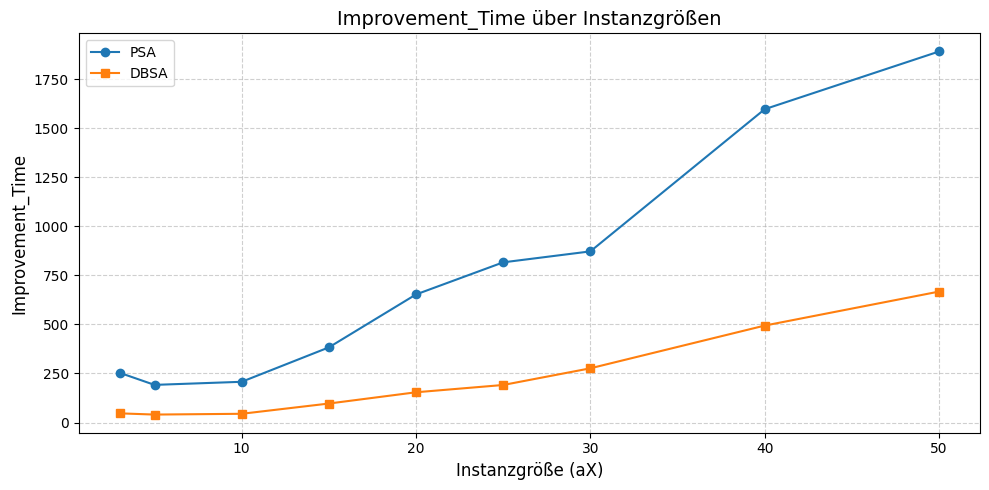

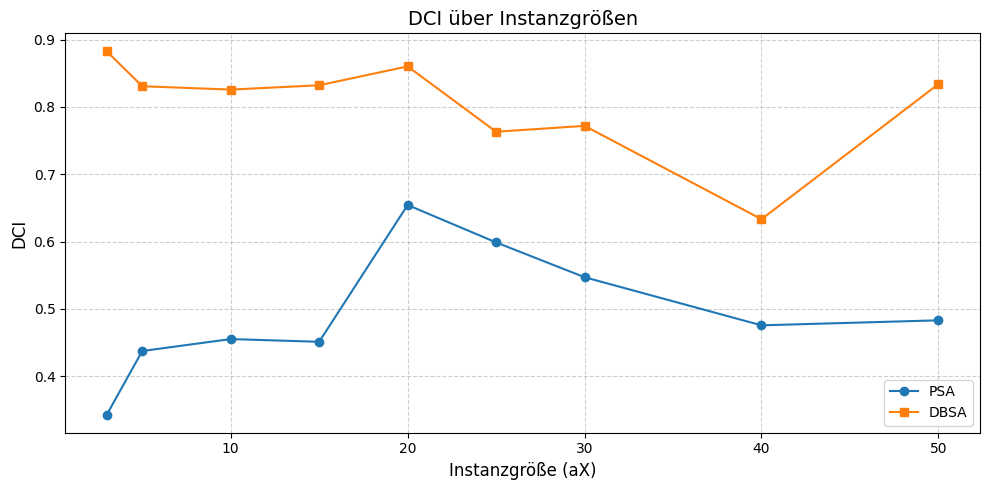

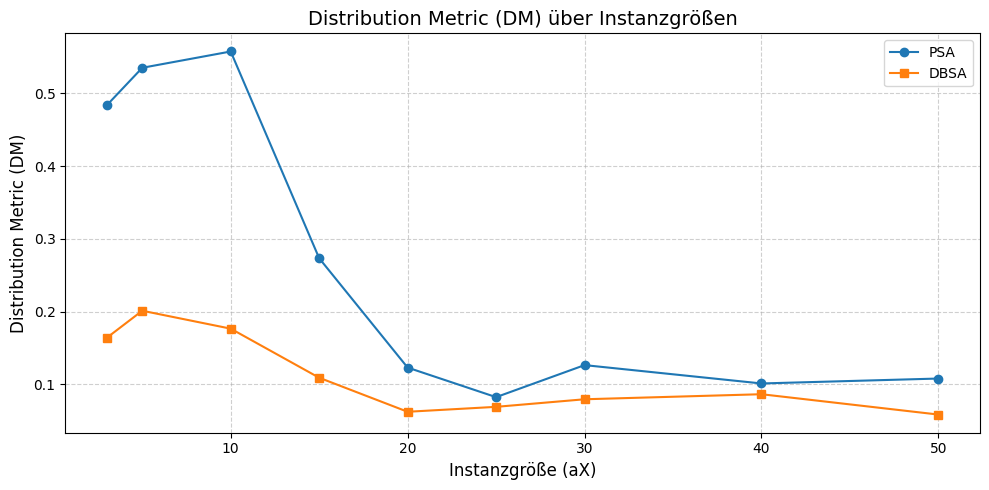

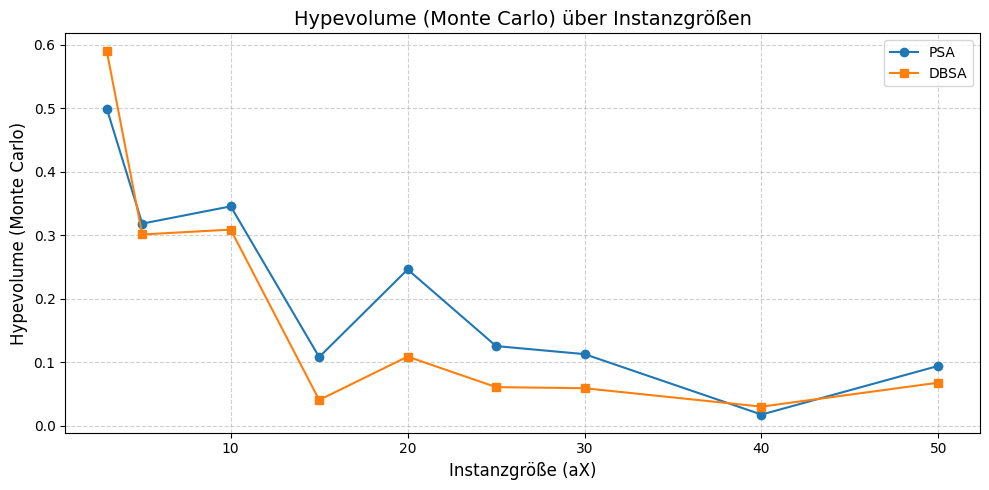

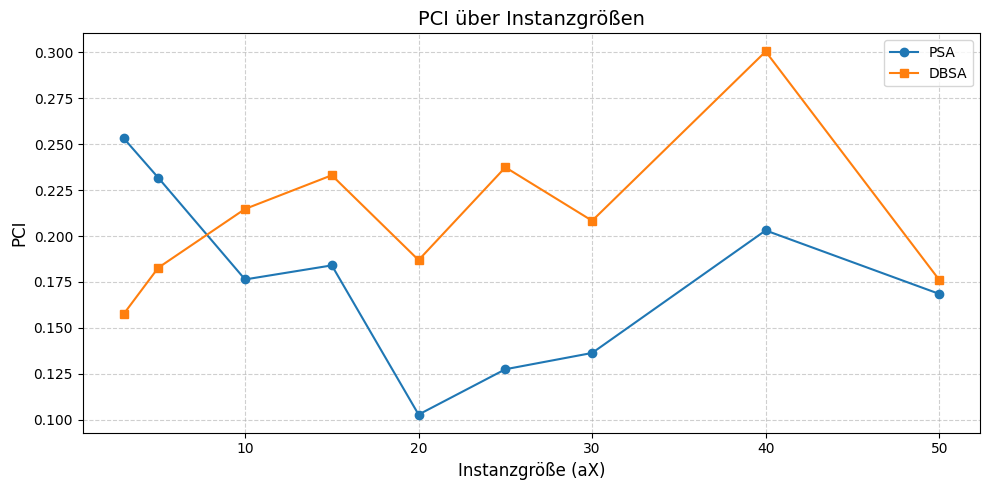

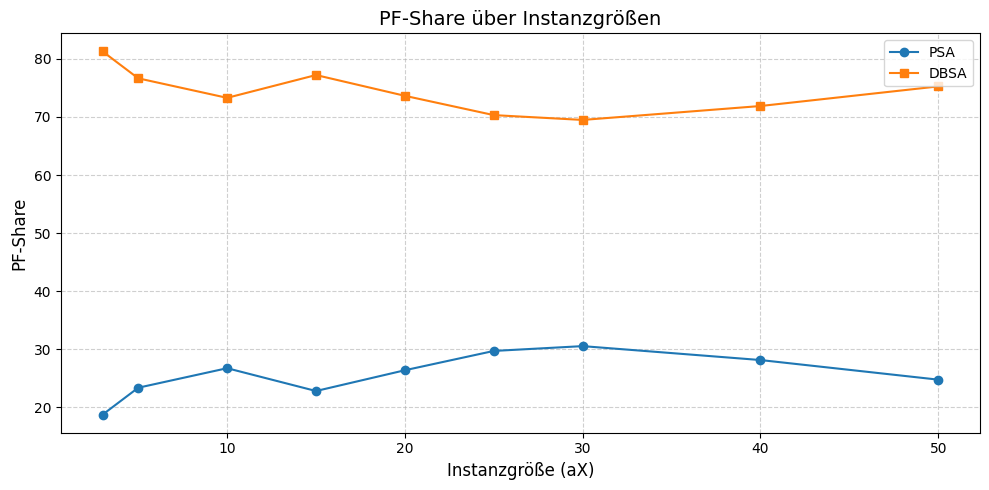

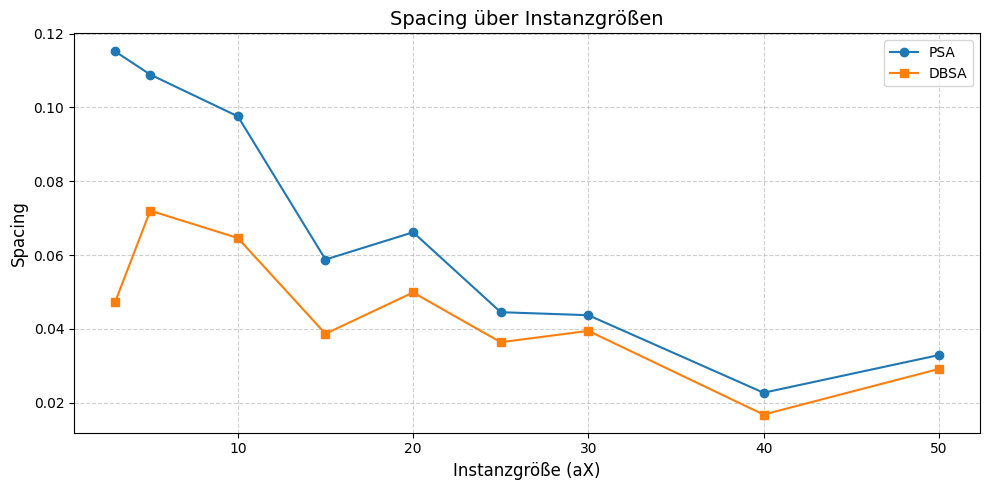

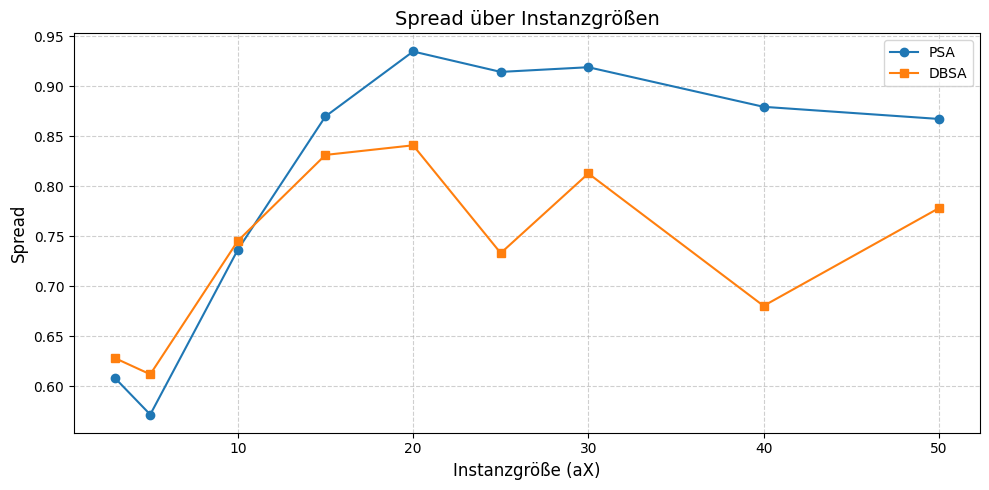

In [7]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt

# 📂 Datei einlesen
file_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_multiple_seeds/Metrics_averaged.csv"
df = pd.read_csv(file_path)

# 🔍 Instanzgröße extrahieren (z. B. 'a3_o80' → 3)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🧹 Metriken auswählen (alle außer 'Instance', 'Algorithm', 'Instance_Size')
metrics = [col for col in df.columns if col not in ["Instance", "Algorithm", "Instance_Size"]]

# 🧮 Mittelwert pro (Instance_Size, Algorithm)
agg_df = df.groupby(["Instance_Size", "Algorithm"], as_index=False)[metrics].mean()

# 📊 Sortieren nach Instanzgröße
agg_df = agg_df.sort_values("Instance_Size")

# 🎨 Visualisierung: Jede Metrik als eigenes Diagramm
for metric in metrics:
    plt.figure(figsize=(10, 5))

    # PSA-Linie
    psa_data = agg_df[agg_df["Algorithm"] == "PSA"]
    plt.plot(psa_data["Instance_Size"], psa_data[metric], marker="o", label="PSA")

    # DBSA-Linie
    dbsa_data = agg_df[agg_df["Algorithm"] == "DBSA"]
    plt.plot(dbsa_data["Instance_Size"], dbsa_data[metric], marker="s", label="DBSA")

    # ✨ Formatierung
    plt.title(f"{metric} über Instanzgrößen", fontsize=14)
    plt.xlabel("Instanzgröße (aX)", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [5]:
# Durchschnittswerte je Algorithmus
df.groupby("Algorithm").mean(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
Algorithm,,,,,,,,
DBSA,178.830,0.809,0.128,0.208,0.212,74.084,0.049,0.742
PSA,624.008,0.484,0.339,0.242,0.176,25.916,0.074,0.793
